In [1]:
import pandas as pd
import random
import pickle
import numpy as np
import math
import matplotlib.pyplot as plt
import os

from collections import defaultdict

In [2]:
load_path = "../../data/Georgios/pcy_pass2/pcy_pass2_frequent_pairs.pkl"

with open(load_path, "rb") as f:
    data = pickle.load(f)

frequent_pairs = data["frequent_pairs"]
item_counts = data["item_counts"]
num_buckets = data["num_buckets"]
support_threshold = data["support_threshold"]

print("Loaded frequent pairs:", len(frequent_pairs))


Loaded frequent pairs: 74


<h3> <span style="color:green; font-weight:bold; background-color: #f0f0f0; padding: 6px; border-radius: 4px;">
Checking Loaded PCY Results </span> </h3>

This step simply verifies that the data stored from PCY Pass 2 has been loaded correctly.  
It confirms that the frequent pairs, item counts, and configuration values match the original computation before continuing with the analysis.

In [3]:
# Sort by frequency descending
sorted_pairs = sorted(frequent_pairs.items(), key=lambda x: x[1], reverse=True)

print("Top 10 frequent pairs after loading pickle:\n")
for i, ((a, b), count) in enumerate(sorted_pairs[:10]):
    print(f"{i+1}. ({a}, {b}) → {count}")

Top 10 frequent pairs after loading pickle:

1. (13176, 47209) → 62341
2. (13176, 21137) → 61628
3. (21137, 24852) → 56156
4. (24852, 47766) → 53395
5. (21903, 24852) → 51395
6. (13176, 21903) → 50372
7. (16797, 24852) → 41232
8. (24852, 47626) → 40880
9. (21137, 47209) → 40794
10. (13176, 27966) → 40503


<h3><span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Merging Orders with Product Data
</span></h3>

This step combines the `orders` and `order_products__prior` tables in order to attach  
a `user_id` to every purchased `product_id`.  
The result allows identifying which user bought which products across all orders.

In [4]:
orders = pd.read_csv("../../data/orders.csv")
order_products = pd.read_csv("../../data/order_products__prior.csv")

# Merge to attach user_id to each product_id
merged = order_products.merge(orders[["order_id", "user_id"]], on="order_id")

# Build user → set of purchased products
user_baskets = merged.groupby("user_id")["product_id"].apply(set).to_dict()

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Loading Product Metadata
</span></h3>

The product catalog is loaded and a mapping from `product_id` to `product_name` is created.  
This mapping enables converting frequent item pairs from numeric IDs into readable product names.

In [5]:
# Load products and create mapping product_id -> product_name
products_df = pd.read_csv("../../data/products.csv")
id_to_name = dict(zip(products_df["product_id"], products_df["product_name"]))

<span style="display:inline-block; background-color:#f0f0f0; padding:6px 10px; border-radius:4px; font-size:22px; font-weight:bold;">
  <span style="color:red;">Reconstructing</span>
  <span style="color:green;">Transaction Baskets</span>
</span>


Each order is transformed into a list of purchased product IDs,  
creating the complete set of customer baskets.  
This dataset is required to compute support, confidence, and lift  
for the association rules derived from the PCY frequent pairs.


In [6]:
# Rebuild baskets from order_products (one basket per order_id)
baskets_series = order_products.groupby("order_id")["product_id"].apply(list)
baskets = baskets_series.tolist()

N = len(baskets)  # total number of baskets
print("Number of baskets:", N)

Number of baskets: 3214874


<span style="display:inline-block; background-color:#f0f0f0; padding:6px 10px; border-radius:4px; font-size:22px; font-weight:bold;">
    <span style="color:red;">Rebuilding</span>
    <span style="color:green;">Association Rules from Frequent Pairs</span>
</span>
 

Using the saved PCY frequent pairs and the reconstructed baskets,  
support, confidence, and lift are recalculated for every item pair.  
The resulting rules are stored in `df_rules` and sorted by lift,  
preparing the dataset for personalized product recommendations.


In [7]:
# Rebuild df_rules from frequent_pairs and item_counts

rules = []
N = len(baskets)   # total number of baskets

for (a, b), pair_cnt in frequent_pairs.items():

    # support(pair)
    support_ab = pair_cnt / N

    # support(A), support(B)
    support_a = item_counts[a] / N
    support_b = item_counts[b] / N

    # confidence
    conf_a_b = support_ab / support_a
    conf_b_a = support_ab / support_b

    # lift
    lift_ab = support_ab / (support_a * support_b)

    rules.append({
        "A": id_to_name[a],
        "B": id_to_name[b],
        "support": support_ab,
        "confidence_A_to_B": conf_a_b,
        "confidence_B_to_A": conf_b_a,
        "lift": lift_ab
    })

# Convert to dataframe
df_rules = pd.DataFrame(rules)

# Sort by lift descending
df_rules = df_rules.sort_values(by="lift", ascending=False).reset_index(drop=True)

print("df_rules created successfully!")
df_rules.head()


df_rules created successfully!


,A,B,support,confidence_A_to_B,confidence_B_to_A,lift
0,Limes,Organic Cilantro,0.005464,0.124905,0.252647,5.775753
1,Organic Yellow Onion,Organic Garlic,0.006866,0.194603,0.201069,5.698983
2,Limes,Large Lemon,0.008524,0.194863,0.179507,4.103710
3,Organic Lemon,Organic Hass Avocado,0.006609,0.242131,0.099474,3.644560
4,Organic Cucumber,Organic Hass Avocado,0.005430,0.217136,0.081729,3.268339


<span style="display:inline-block; background-color:#f0f0f0; padding:6px 10px; border-radius:4px; font-size:22px; font-weight:bold;">
  <span style="color:blue;">Personalized Recommendation System</span>
</span>

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Load & Prepare User Baskets (PRIOR/TRAIN) + Recency Field
</span></h3>

- Loads Instacart CSVs and builds `product_id → product_name`.  
- Merges `orders` to attach `user_id` & `order_number` (needed for repeat/recency).  
- Creates per-user baskets:
  - `user_baskets` from PRIOR (history for rules),
  - `future_baskets` from TRAIN (for evaluation).  
- Computes `users_with_future` and prints quick sanity counts.  
- Includes light schema checks to fail fast if required columns are missing.


In [8]:
# Core datasets
df_prior  = pd.read_csv("../../data/order_products__prior.csv")
df_train  = pd.read_csv("../../data/order_products__train.csv")
orders    = pd.read_csv("../../data/orders.csv")
products  = pd.read_csv("../../data/products.csv")

# Schema guards (fail fast)
required_orders_cols = {"order_id", "user_id", "order_number"}
required_prior_cols  = {"order_id", "product_id"}
required_train_cols  = {"order_id", "product_id"}
required_prod_cols   = {"product_id", "product_name"}

assert required_orders_cols.issubset(orders.columns),   "orders missing required columns"
assert required_prior_cols.issubset(df_prior.columns),  "prior missing required columns"
assert required_train_cols.issubset(df_train.columns),  "train missing required columns"
assert required_prod_cols.issubset(products.columns),   "products missing required columns"

# product_id → product_name
id_to_name = dict(zip(products["product_id"], products["product_name"]))

# Keep only what's needed; order_number is used for recency in repeat scoring
orders_small = orders[["order_id", "user_id", "order_number"]]

# Attach user_id (+ order_number) to lines in PRIOR and TRAIN
prior_merged = df_prior.merge(orders_small, on="order_id", how="inner")
train_merged = df_train.merge(orders_small, on="order_id", how="inner")

# PRIOR baskets = training history for rules
user_baskets = prior_merged.groupby("user_id")["product_id"].apply(set).to_dict()

# TRAIN baskets = future purchases for evaluation
future_baskets = train_merged.groupby("user_id")["product_id"].apply(set).to_dict()

# Users with both past and future
users_with_future = set(user_baskets.keys()) & set(future_baskets.keys())

print("Users with history (PRIOR):", len(user_baskets))
print("Users with future (TRAIN):", len(future_baskets))
print("Users with both:", len(users_with_future))
print("Example users:", list(users_with_future)[:10])


Users with history (PRIOR): 206209
Users with future (TRAIN): 131209
Users with both: 131209
Example users: [1, 2, 5, 7, 8, 9, 10, 13, 14, 17]


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Deduplicate (A,B) Rules + Rebuild rule_map (AGG_MODE with Confidence Tie-Break)
</span></h3>

- Guarantees **one row per (A,B)** in `df_rules` before building `rule_map`.
- `AGG_MODE`: `"max"` (default, tie-break by higher `confidence_A_to_B"`), `"mean"`, or `"median"`.
- Prints removal stats (rows/pairs) for audit; asserts no duplicates remain.
- Rebuilds `rule_map[A] → [(B, lift)]` sorted by lift (desc).

In [9]:
# Requires: import numpy as np, import pandas as pd
AGG_MODE = "max"  # options: "max", "mean", "median"

assert {"A","B","lift"}.issubset(df_rules.columns), "df_rules must include columns: A,B,lift"

before_rows  = len(df_rules)
before_pairs = df_rules[["A","B"]].drop_duplicates().shape[0]

def _dedup_max_with_tiebreak(df: pd.DataFrame) -> pd.DataFrame:
    # Secondary key: confidence_A_to_B if present (why: prefer stronger/confident rules)
    sort_cols = ["A", "B", "lift"]
    ascending = [True, True, False]
    if "confidence_A_to_B" in df.columns:
        sort_cols.append("confidence_A_to_B")
        ascending.append(False)
    return (
        df.sort_values(sort_cols, ascending=ascending)
            .drop_duplicates(subset=["A","B"], keep="first")
            .reset_index(drop=True)
    )

if AGG_MODE == "max":
    df_rules_dedup = _dedup_max_with_tiebreak(df_rules)
elif AGG_MODE in {"mean", "median"}:
    _agg_fn = (np.mean if AGG_MODE == "mean" else np.median)
    num_cols = [c for c in ["support","confidence_A_to_B","confidence_B_to_A","lift"] if c in df_rules.columns]
    agg_spec = {c: _agg_fn for c in num_cols}
    df_rules_dedup = (
        df_rules.groupby(["A","B"], as_index=False)
                .agg(agg_spec)
                .sort_values("lift", ascending=False)
                .reset_index(drop=True)
    )
else:
    raise ValueError("Invalid AGG_MODE. Use one of: 'max', 'mean', 'median'.")

after_rows  = len(df_rules_dedup)
after_pairs = df_rules_dedup[["A","B"]].drop_duplicates().shape[0]
removed_rows  = before_rows  - after_rows
removed_pairs = before_pairs - after_pairs
pct_rows = (removed_rows / before_rows * 100) if before_rows else 0.0

print("=== Rules Dedup Summary (AGG_MODE:", AGG_MODE, ") ===")
print(f"Rows: before={before_rows}  after={after_rows}  removed={removed_rows} ({pct_rows:.2f}%)")
print(f"(A,B) pairs: before={before_pairs}  after={after_pairs}  removed_pairs={removed_pairs}")

# Build rule_map from deduped rules
rule_map = {}
for _, row in df_rules_dedup.iterrows():
    A, B, lift = row["A"], row["B"], float(row["lift"])
    rule_map.setdefault(A, []).append((B, lift))

for A in rule_map:
    rule_map[A].sort(key=lambda x: x[1], reverse=True)

# Safety guard
assert df_rules_dedup.duplicated(subset=["A","B"]).sum() == 0, "Duplicate (A,B) remain after dedup"

=== Rules Dedup Summary (AGG_MODE: max ) ===
Rows: before=74  after=74  removed=0 (0.00%)
(A,B) pairs: before=74  after=74  removed_pairs=0


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Lift-Based NOVEL Recommender (Top-K, Excludes Previously Bought)
</span></h3>

- Aggregates **lift** from rules `A→B` over the user’s purchased items `A`.  
- Excludes items already bought (**novel** only).  
- Deterministic ranking (tie-break by item name).  
- **Inputs:** `user_baskets`, `id_to_name`, `rule_map`. **Output:** list of `(item_name, score)`.


In [10]:
def recommend_for_user(user_id: int, top_k: int = 5):
    """Lift-aggregated NOVEL recommendations (skip already purchased)."""
    if user_id not in user_baskets:
        return []

    purchased_ids = user_baskets[user_id]
    purchased_names = {id_to_name[i] for i in purchased_ids if i in id_to_name}

    candidates: dict[str, float] = {}
    for A in purchased_names:
        if A not in rule_map:
            continue
        for B, lift_score in rule_map[A]:
            if B in purchased_names:
                continue
            candidates[B] = candidates.get(B, 0.0) + float(lift_score)

    # Stable deterministic order: score desc, then name asc
    ranked = sorted(candidates.items(), key=lambda x: (-x[1], x[0]))[:top_k]
    return ranked  # list[(item_name, score)]

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Rule-Based Recommender (precomputed confidence map, deterministic ranking)
</span></h3>

- Precomputes a global **`CONF_MAP[(A,B)] → confidence_A_to_B`** from `df_rules_dedup` (one-time) for faster lookups.
- `recommend_with_explanations(user_id, top_k, allow_repeat)`:
  - Aggregates **lift** over rules `A→B` from the user’s purchased `A`.
  - Controls repeats via `allow_repeat` (`False` = NOVEL-only).
  - Builds compact **explanations** per item (lift + confidence if available).
  - Deterministic sort: **score desc**, then **item name asc**.
- **Inputs:** `rule_map`, `df_rules_dedup`, `user_baskets`, `id_to_name`. **Output:** `[{recommended_item, score, explanations}]`.


In [11]:
# After df_rules_dedup exists (one-time)
if {"A","B","confidence_A_to_B"}.issubset(df_rules_dedup.columns):
    CONF_MAP = {
        (row["A"], row["B"]): float(row["confidence_A_to_B"])
        for _, row in df_rules_dedup.iterrows()
        if pd.notna(row.get("confidence_A_to_B", None))
    }
else:
    CONF_MAP = {}

def recommend_with_explanations(user_id: int, top_k: int = 5, allow_repeat: bool = False):
    if user_id not in user_baskets:
        return []
    purchased_names = {id_to_name[i] for i in user_baskets[user_id] if i in id_to_name}
    explanations, scores = {}, {}
    for A in purchased_names:
        for B, lift_score in rule_map.get(A, []):
            if (not allow_repeat) and (B in purchased_names):
                continue
            explanations.setdefault(B, [])
            scores[B] = scores.get(B, 0.0) + float(lift_score)
            conf = CONF_MAP.get((A, B))
            msg = (f"because you bought '{A}' (lift={float(lift_score):.2f}"
                   + (f", confidence={conf:.2f})" if conf is not None else ")"))
            explanations[B].append(msg)
    ranked = sorted(scores.items(), key=lambda x: (-x[1], x[0]))[:top_k]
    return [{"recommended_item": it, "score": sc, "explanations": explanations[it]} for it, sc in ranked]


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Repeat Stats with Min-Freq Filter + Per-User Normalized Recency (safe dtypes & fallback)
</span></h3>

- Computes per `(user_id, product_id)` **freq** and **last_order_number** from PRIOR.
- Filters by `MIN_FREQ` (default 2). Keeps an **unfiltered copy** for potential fallbacks.
- Adds **`norm_last_onum`** ∈ [0,1] per user (0=oldest, 1=newest). Safe when user has one order.
- Cleans dtypes (numeric) and drops corrupted rows.
- Prints kept ratio; warns if the filter empties the table.


In [12]:
# Config
MIN_FREQ = 2  # keep only user-item pairs seen at least this many times

# Guards
assert {"user_id", "product_id", "order_number"}.issubset(prior_merged.columns), \
    "prior_merged must have user_id, product_id, order_number"

# Aggregates
group = prior_merged.groupby(["user_id", "product_id"], sort=False)
user_item_freq = group.size().rename("freq").reset_index()
user_item_last_onum = group["order_number"].max().rename("last_order_number").reset_index()

# Merge
user_item_stats = user_item_freq.merge(user_item_last_onum, on=["user_id", "product_id"], how="inner")

# Dtypes → numeric; drop bad rows if any
for c in ["user_id", "product_id", "freq", "last_order_number"]:
    user_item_stats[c] = pd.to_numeric(user_item_stats[c], errors="coerce")
user_item_stats = user_item_stats.dropna(subset=["user_id", "product_id", "freq", "last_order_number"]).copy()

# Keep an unfiltered copy (optional fallback for very light users)
user_item_stats_full = user_item_stats.copy()

# Filter by min frequency
before_rows = len(user_item_stats)
user_item_stats = user_item_stats[user_item_stats["freq"] >= MIN_FREQ].copy()
after_rows = len(user_item_stats)

# Per-user min–max normalization of recency
# norm_last_onum = 0 for a user's oldest, 1 for newest (safe when max==min)
if not user_item_stats.empty:
    u_min = user_item_stats.groupby("user_id")["last_order_number"].transform("min")
    u_max = user_item_stats.groupby("user_id")["last_order_number"].transform("max")
    den = (u_max - u_min).replace(0, 1)  # avoid div-by-zero
    user_item_stats["norm_last_onum"] = (user_item_stats["last_order_number"] - u_min) / den
else:
    user_item_stats["norm_last_onum"] = pd.Series(dtype=float)

kept_pct = (after_rows / max(before_rows, 1)) * 100.0
print(f"[Repeat stats] rows before={before_rows} after_freq≥{MIN_FREQ}={after_rows}; kept={kept_pct:.2f}%")
if after_rows == 0:
    print("[WARN] All rows filtered by MIN_FREQ. Consider using fallback or lowering MIN_FREQ.")


[Repeat stats] rows before=13307953 after_freq≥2=5325258; kept=40.02%


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Repeat & Hybrid Recommenders (Freq + Normalized Recency) and Rule Blend
</span></h3>

- **Repeat:** `score_repeat = freq + λ·norm_last_onum` (uses per-user normalized recency; fallback to freq≥1 if needed).  
- **Hybrid:** Min–max normalizes NOVEL/REPEAT scores and blends: `final = α·novel + (1−α)·repeat`.  
- Deterministic sort (score ↓, name ↑).  
- **Inputs:** `user_item_stats` (with `norm_last_onum`), `user_item_stats_full` (fallback), `user_baskets`, `id_to_name`, `recommend_with_explanations`.  
- **Tune:** `RECENCY_LAMBDA` (recency weight), `alpha` (novel vs repeat).

In [13]:
# Config: recency weight in repeat score
RECENCY_LAMBDA = 0.5  # increase to emphasize recency more

def _safe_name(pid: int) -> str:
    return id_to_name.get(pid, f"product_id={pid}")

def recommend_repeats(user_id: int, top_k: int = 5):
    """Repeat recommendations ranked by freq + RECENCY_LAMBDA*norm_last_onum, with per-user fallback."""
    if user_id not in user_baskets:
        return []

    # Primary: precomputed stats with MIN_FREQ filter & normalized recency
    subset = user_item_stats[user_item_stats["user_id"] == user_id]

    # Fallback: if MIN_FREQ filtered everything for this user, use unfiltered stats (freq>=1)
    if subset.empty:
        if "user_item_stats_full" in globals():
            subset = user_item_stats_full[user_item_stats_full["user_id"] == user_id].copy()
            if subset.empty:
                return []
            # ensure normalized recency exists
            umin, umax = subset["last_order_number"].min(), subset["last_order_number"].max()
            subset["norm_last_onum"] = 1.0 if umax == umin else (subset["last_order_number"] - umin) / (umax - umin)
        else:
            return []

    tmp = subset.copy()
    # composite repeat score
    tmp["score_repeat"] = tmp["freq"] + RECENCY_LAMBDA * tmp["norm_last_onum"]

    # deterministic sorting: score desc, then name asc
    tmp["__name"] = tmp["product_id"].apply(_safe_name)
    tmp = tmp.sort_values(["score_repeat", "__name"], ascending=[False, True]).head(top_k)

    results = []
    for _, row in tmp.iterrows():
        pid = int(row["product_id"])
        name = row["__name"]
        freq = int(row["freq"])
        recn = float(row["norm_last_onum"])
        score = float(row["score_repeat"])
        results.append({
            "recommended_item": name,
            "score": score,
            "explanations": [f"you bought it {freq} times (recency={recn:.2f})"],
        })
    return results

def _normalize_scores(recs):
    """Min–max normalize scores within a list of dict recs."""
    if not recs:
        return {}
    vals = [float(r["score"]) for r in recs]
    vmin, vmax = min(vals), max(vals)
    if vmax == vmin:
        return {r["recommended_item"]: 1.0 for r in recs}
    return {r["recommended_item"]: (float(r["score"]) - vmin) / (vmax - vmin) for r in recs}

def recommend_hybrid(user_id: int, top_k: int = 5, alpha: float = 0.6):
    """Blend NOVEL (rules) and REPEAT (freq+recency) after per-list normalization."""
    # widen candidate pools a bit to improve overlap after normalization
    widen = max(1, top_k * 3)

    novel  = recommend_with_explanations(user_id, top_k=widen, allow_repeat=False)
    repeat = recommend_repeats(user_id,          top_k=widen)

    novel_n  = _normalize_scores(novel)
    repeat_n = _normalize_scores(repeat)

    combined, exps = {}, {}
    for r in novel:
        it = r["recommended_item"]
        combined[it] = combined.get(it, 0.0) + alpha * novel_n.get(it, 0.0)
        exps.setdefault(it, []).extend(r.get("explanations", []))

    for r in repeat:
        it = r["recommended_item"]
        combined[it] = combined.get(it, 0.0) + (1 - alpha) * repeat_n.get(it, 0.0)
        exps.setdefault(it, []).extend([f"(repeat) {e}" for e in r.get("explanations", [])])

    # deterministic ranking: score desc, name asc
    ranked = sorted(combined.items(), key=lambda x: (-x[1], x[0]))[:top_k]
    return [{"recommended_item": it, "score": sc, "explanations": exps.get(it, [])} for it, sc in ranked]


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Build Inverse Index with Rare-Item Filter (for stabler Diversity)
</span></h3>

- Builds `product_to_users[item_name] = {user_ids…}` from PRIOR, **filtering out very rare items** (default: seen by `< 3` users).  
- Optional: persists to pickle for reuse.  
- No other cells need changes; only diversity calculations become less noisy.


In [ ]:
# Config
MIN_USERS_PER_ITEM = 3         # drop items seen by fewer than this many users
SAVE_PICKLE = False            # set True to persist for reuse
PICKLE_PATH = "product_to_users.pkl"

# Build inverse index (raw)
_counts = defaultdict(int)
_tmp_ix = defaultdict(set)

for uid, prod_ids in user_baskets.items():
    for pid in prod_ids:
        name = id_to_name.get(pid)
        if name is None:
            continue
        _tmp_ix[name].add(uid)

# Filter rare items
product_to_users = {
    name: users for name, users in _tmp_ix.items()
    if len(users) >= MIN_USERS_PER_ITEM
}

print(f"Products (raw)     : {len(_tmp_ix)}")
print(f"Products (kept≥{MIN_USERS_PER_ITEM} users): {len(product_to_users)}")
if SAVE_PICKLE:
    with open(PICKLE_PATH, "wb") as f:
        pickle.dump(product_to_users, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"[saved] {PICKLE_PATH}")


Products (raw)     : 49677
Products (kept≥3 users): 49038


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Evaluate NOVEL vs REPEAT vs HYBRID @k=5 (Precision · Coverage · Novelty · Diversity)
</span></h3>

- Samples users and computes per-strategy metrics:
  - **Precision@5** = hits in TRAIN / k
  - **Coverage@5** = users with ≥1 rec
  - **Novelty@5** = share of recs not seen in PRIOR
  - **Diversity@5** = mean (1 − Jaccard) across recommended pairs (uses the filtered `product_to_users`)
- Prints a compact summary table and bar charts (one chart per metric).  
- Safe-guards: handles empty lists, and can **toggle diversity** via `COMPUTE_DIVERSITY`.  
- **Inputs:** `users_with_future`, `user_baskets`, `future_baskets`, `id_to_name`, `product_to_users`, `recommend_with_explanations`, `recommend_repeats`, `recommend_hybrid`.  
- **Outputs:** `summary` DataFrame + console print + plots.

Processed 50/2000 users...
Processed 100/2000 users...
Processed 150/2000 users...
Processed 200/2000 users...
Processed 250/2000 users...
Processed 300/2000 users...
Processed 350/2000 users...
Processed 400/2000 users...
Processed 450/2000 users...
Processed 500/2000 users...
Processed 550/2000 users...
Processed 600/2000 users...
Processed 650/2000 users...
Processed 700/2000 users...
Processed 750/2000 users...
Processed 800/2000 users...
Processed 850/2000 users...
Processed 900/2000 users...
Processed 950/2000 users...
Processed 1000/2000 users...
Processed 1050/2000 users...
Processed 1100/2000 users...
Processed 1150/2000 users...
Processed 1200/2000 users...
Processed 1250/2000 users...
Processed 1300/2000 users...
Processed 1350/2000 users...
Processed 1400/2000 users...
Processed 1450/2000 users...
Processed 1500/2000 users...
Processed 1550/2000 users...
Processed 1600/2000 users...
Processed 1650/2000 users...
Processed 1700/2000 users...
Processed 1750/2000 users...
Proce

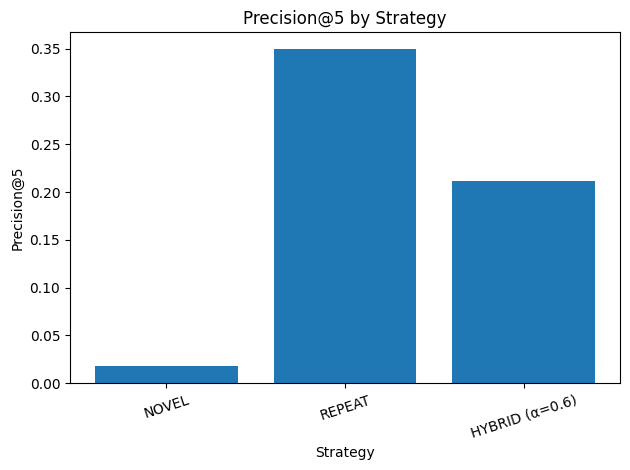

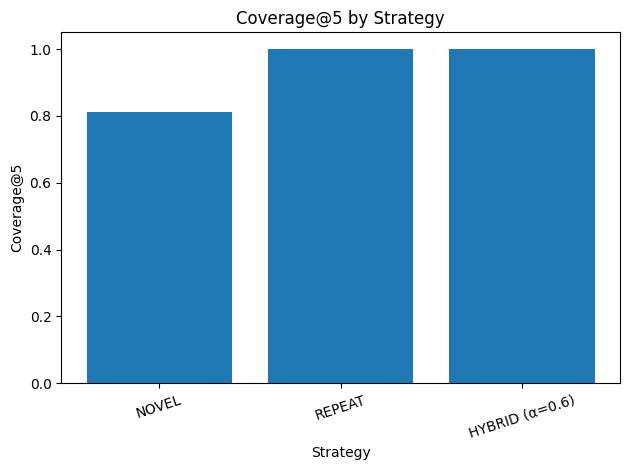

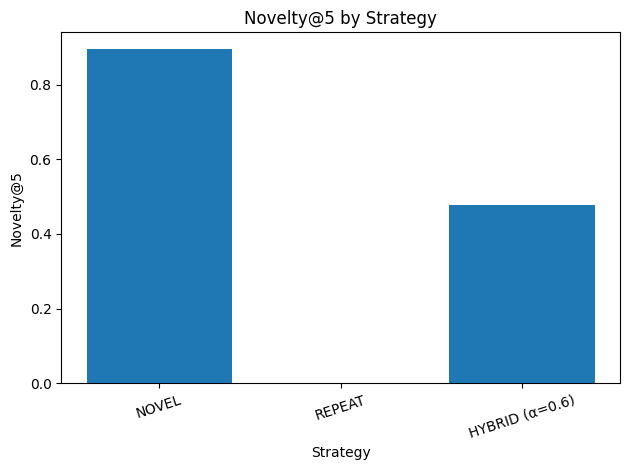

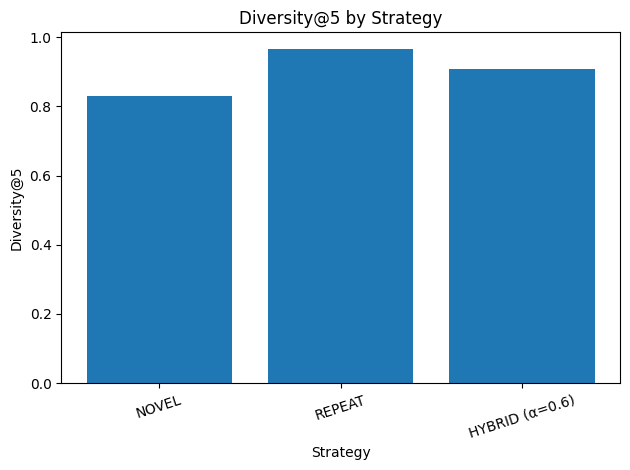

In [15]:
# Params
random.seed(42)
k = 5
alpha = 0.6
sample_size = 2000
COMPUTE_DIVERSITY = True  # set False to skip Diversity@5

# Use filtered product_to_users if available
if "product_to_users" not in globals():
    product_to_users = {}

sample_users = random.sample(list(users_with_future), min(sample_size, len(users_with_future)))

def _recommended_set_from_recs(recs):
    return {r["recommended_item"] for r in (recs or [])}

def _future_purchased_names(user_id):
    if user_id not in future_baskets:
        return set()
    return {id_to_name[p] for p in future_baskets[user_id] if p in id_to_name}

def _diversity_from_items(items):
    if not COMPUTE_DIVERSITY:
        return None
    items = list(items)
    if len(items) < 2:
        return 1.0
    distances = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            a, b = items[i], items[j]
            users_A = product_to_users.get(a, set())
            users_B = product_to_users.get(b, set())
            union = len(users_A | users_B)
            if union == 0:
                distances.append(1.0)
            else:
                inter = len(users_A & users_B)
                jaccard_sim = inter / union
                distances.append(1.0 - jaccard_sim)
    return sum(distances) / len(distances)

# todo, temp comment out def _avg to try avoid TypeError, 
# def _avg(xs):
#     xs = [x for x in xs if x is not None and not math.isnan(x)]
#     return (sum(xs) / len(xs)) if xs else 0.0

def _avg(xs):
    vals = []
    for x in xs:
        if x is None:
            continue
        try:
            if math.isnan(x):
                continue
        except TypeError:
            # μη-αριθμητικό -> το αγνοούμε
            pass
        vals.append(float(x))
    return (sum(vals) / len(vals)) if vals else 0.0

novel_precisions, novel_novelties, novel_diversities = [], [], []
repeat_precisions, repeat_diversities = [], []
hybrid_precisions, hybrid_novelties, hybrid_diversities = [], [], []
novel_nonempty = repeat_nonempty = hybrid_nonempty = 0

for idx, uid in enumerate(sample_users, start=1):
    # NOVEL
    recs_novel = recommend_with_explanations(uid, top_k=k, allow_repeat=False)
    if recs_novel:
        novel_nonempty += 1
        rec_items = _recommended_set_from_recs(recs_novel)
        future_names = _future_purchased_names(uid)
        novel_precisions.append(len(rec_items & future_names) / k)
        purchased_before = {id_to_name[x] for x in user_baskets.get(uid, set()) if x in id_to_name}
        novel_novelties.append(len(rec_items - purchased_before) / k)
        novel_diversities.append(_diversity_from_items(rec_items))
    else:
        novel_precisions.append(None); novel_novelties.append(None); novel_diversities.append(None)

    # REPEAT
    recs_repeat = recommend_repeats(uid, top_k=k)
    if recs_repeat:
        repeat_nonempty += 1
        rec_items = _recommended_set_from_recs(recs_repeat)
        future_names = _future_purchased_names(uid)
        repeat_precisions.append(len(rec_items & future_names) / k)
        repeat_diversities.append(_diversity_from_items(rec_items))
    else:
        repeat_precisions.append(None); repeat_diversities.append(None)

    # HYBRID
    recs_hybrid = recommend_hybrid(uid, top_k=k, alpha=alpha)
    if recs_hybrid:
        hybrid_nonempty += 1
        rec_items = _recommended_set_from_recs(recs_hybrid)
        future_names = _future_purchased_names(uid)
        hybrid_precisions.append(len(rec_items & future_names) / k)
        purchased_before = {id_to_name[x] for x in user_baskets.get(uid, set()) if x in id_to_name}
        hybrid_novelties.append(len(rec_items - purchased_before) / k)
        hybrid_diversities.append(_diversity_from_items(rec_items))
    else:
        hybrid_precisions.append(None); hybrid_novelties.append(None); hybrid_diversities.append(None)

    if idx % 50 == 0:
        print(f"Processed {idx}/{len(sample_users)} users...")

# Build summary
rows = [
    ["NOVEL",
        round(_avg(novel_precisions), 4),
        round(novel_nonempty/len(sample_users), 4),
        round(_avg(novel_novelties), 4),
        round(_avg(novel_diversities), 4) if COMPUTE_DIVERSITY else None],

    ["REPEAT",
        round(_avg(repeat_precisions), 4),
        round(repeat_nonempty/len(sample_users), 4),
        0.0,
        round(_avg(repeat_diversities), 4) if COMPUTE_DIVERSITY else None],

    [f"HYBRID (α={alpha})",
        round(_avg(hybrid_precisions), 4),
        round(hybrid_nonempty/len(sample_users), 4),
        round(_avg(hybrid_novelties), 4),
        round(_avg(hybrid_diversities), 4) if COMPUTE_DIVERSITY else None],
]

cols = ["Strategy", "Precision@5", "Coverage@5", "Novelty@5"] + (["Diversity@5"] if COMPUTE_DIVERSITY else [])
summary = pd.DataFrame(rows, columns=cols)

print("\n=== COMPARISON @k=5 ===")
print(summary.to_string(index=False))

# Bar charts (skip diversity if disabled)
plot_metrics = ["Precision@5", "Coverage@5", "Novelty@5"]
if COMPUTE_DIVERSITY:
    plot_metrics.append("Diversity@5")

for metric in plot_metrics:
    plt.figure()
    plt.title(f"{metric} by Strategy")
    plt.bar(summary["Strategy"], summary[metric])
    plt.xlabel("Strategy"); plt.ylabel(metric)
    plt.xticks(rotation=18)
    plt.tight_layout()
    plt.show()


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;"> 
⬆️Quick Read: What the Metrics Say (NOVEL vs REPEAT vs HYBRID) ⬆️</span></h3>

REPEAT → Highest Precision@5 (0.3496) and Coverage (1.0). It consistently recommends items the user already buys, so Novelty=0.0. Great for reorders; low discovery.

NOVEL → Very high Novelty (0.8956) but low Precision (0.0183) and incomplete Coverage (0.812). Useful as a discovery engine, not standalone for production.

HYBRID (α=0.6) → Balanced: Coverage=1.0, Precision=0.2113, Novelty=0.4777, strong Diversity (0.9074). Good trade-off between accuracy and discovery.

Default setting is HYBRID (α≈0.6).
When higher reorder accuracy is required, α is decreased; when greater discovery is desired, α is increased.
</br>⬆️For the best overall performance, an adaptive α is applied per user segment—lower for repeaters, higher for explorers.⬆️

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Random-User Demo: NOVEL / REPEAT / HYBRID with Explanations + Train Purchase Check
</span></h3>

- Picks a random user (up to a few tries) and prints Top-K for:
  - **NOVEL** (rules; excludes previously bought),
  - **REPEAT** (frequency + recency),
  - **HYBRID** (blend with weight `alpha`).
- For each item: shows **score**, compact **why**, and whether it was **bought in TRAIN**.
- Deterministic output formatting; falls back if a user yields no recs.
- **Inputs:** `recommend_with_explanations`, `recommend_repeats`, `recommend_hybrid`, `user_baskets`, `future_baskets`, `id_to_name`.  
- **Next cell:** visualization of these three lists (bar charts).


In [16]:
alpha = 0.6   # weight for NOVEL inside HYBRID
k = 5         # top-K to display

def _future_bought_names(u: int):
    return {id_to_name[p] for p in future_baskets.get(u, set()) if p in id_to_name}

def _print_recs(title: str, recs, future_names):
    print(f"\n--- {title} ---\n")
    if not recs:
        print("(no recommendations)")
        return
    for r in recs:
        # support both tuple (item, score) and dict records
        item = r["recommended_item"] if isinstance(r, dict) else r[0]
        score = r["score"] if isinstance(r, dict) else r[1]
        print("Recommended:", item)
        print("Score:", round(float(score), 3))
        exps = r.get("explanations", []) if isinstance(r, dict) else []
        if exps:
            print("Why:")
            for e in exps:
                print("  -", e)
        print(f"Bought in TRAIN: {'YES' if item in future_names else 'NO'}")
        print()

# Try a few users to avoid picking one with empty recs
example_user = None
for _ in range(10):
    cand = random.choice(list(users_with_future))
    has_any = (
        recommend_with_explanations(cand, top_k=k, allow_repeat=False)
        or recommend_repeats(cand, top_k=k)
        or recommend_hybrid(cand, top_k=k, alpha=alpha)
    )
    if has_any:
        example_user = cand
        break

if example_user is None:
    example_user = random.choice(list(users_with_future))

print("Example user_id:", example_user)
future_purchased_names = _future_bought_names(example_user)

# NOVEL (rules, excludes items the user already bought)
recs_novel = recommend_with_explanations(example_user, top_k=k, allow_repeat=False)
_print_recs("NOVEL (Rules, no repeat)", recs_novel, future_purchased_names)

# REPEAT (already-bought items ranked by frequency + recency)
recs_repeat = recommend_repeats(example_user, top_k=k)
_print_recs("REPEAT (Frequency/Recency)", recs_repeat, future_purchased_names)

# HYBRID (blend of NOVEL and REPEAT using alpha)
recs_hybrid = recommend_hybrid(example_user, top_k=k, alpha=alpha)
_print_recs(f"HYBRID (alpha={alpha})", recs_hybrid, future_purchased_names)


Example user_id: 23642

--- NOVEL (Rules, no repeat) ---

Recommended: Organic Avocado
Score: 7.12
Why:
  - because you bought 'Banana' (lift=2.05, confidence=0.11)
  - because you bought 'Organic Strawberries' (lift=1.65, confidence=0.09)
  - because you bought 'Organic Baby Spinach' (lift=2.32, confidence=0.13)
  - because you bought 'Bag of Organic Bananas' (lift=1.10, confidence=0.06)
Bought in TRAIN: NO

Recommended: Organic Whole Milk
Score: 6.918
Why:
  - because you bought 'Banana' (lift=1.56, confidence=0.07)
  - because you bought 'Organic Strawberries' (lift=2.10, confidence=0.09)
  - because you bought 'Organic Baby Spinach' (lift=1.63, confidence=0.07)
  - because you bought 'Bag of Organic Bananas' (lift=1.63, confidence=0.07)
Bought in TRAIN: NO

Recommended: Limes
Score: 6.399
Why:
  - because you bought 'Banana' (lift=1.54, confidence=0.07)
  - because you bought 'Organic Strawberries' (lift=1.64, confidence=0.07)
  - because you bought 'Organic Baby Spinach' (lift=1.9

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;"> 
⬆️ Quick Read: One-User Snapshot (ID=23642) – NOVEL vs REPEAT vs HYBRID ⬆️
</span></h3>

* **NOVEL** → All 5 suggestions are **new** (TRAIN=NO). Very exploratory; **zero hits** on TRAIN for this user.
* **REPEAT** → 3/5 are **TRAIN=YES** (e.g., milk, strawberries, bananas). Strong for **reorders**; aligns with high precision.
* **HYBRID (α=0.6)** → Top-5 mirrors NOVEL (all **NO**). For this user, normalized repeat scores didn’t dominate at α=0.6, so the blend skewed **toward discovery**.

**Implication:** For this specific user, lowering **α** (or using **adaptive α** based on repeat_ratio) would likely surface more **repeat hits** in HYBRID.
</br>⬆️⬆️

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Visualization: NOVEL / REPEAT / HYBRID Recommendations for Random User
</span></h3>

- Builds tidy `df_viz` for the three strategies and flags **bought in TRAIN**.  
- Draws one horizontal bar chart per strategy; labels include a **✓** when bought.  
- Adds a combined chart with scores **normalized to [0,1] per strategy** for side-by-side comparison.  
- Safe when any list is empty (skips its chart).  
- **Inputs:** `recs_novel`, `recs_repeat`, `recs_hybrid`, `future_purchased_names`. **Output:** quick visual audit.


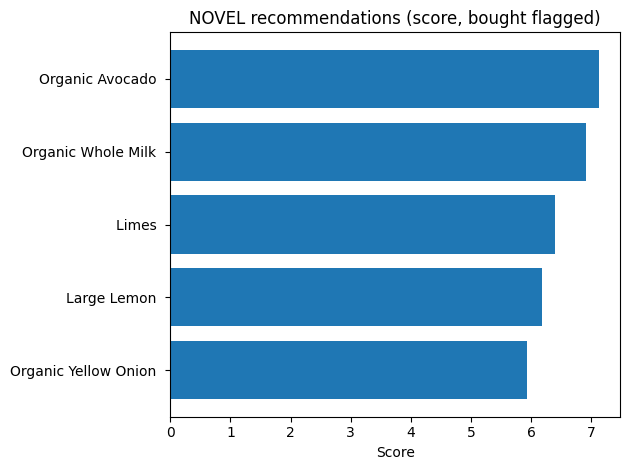

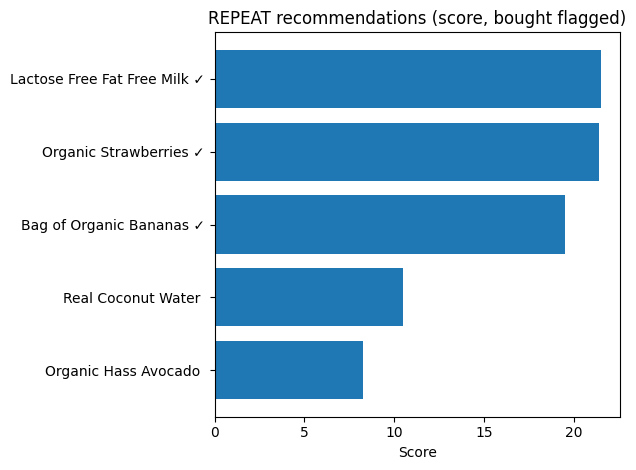

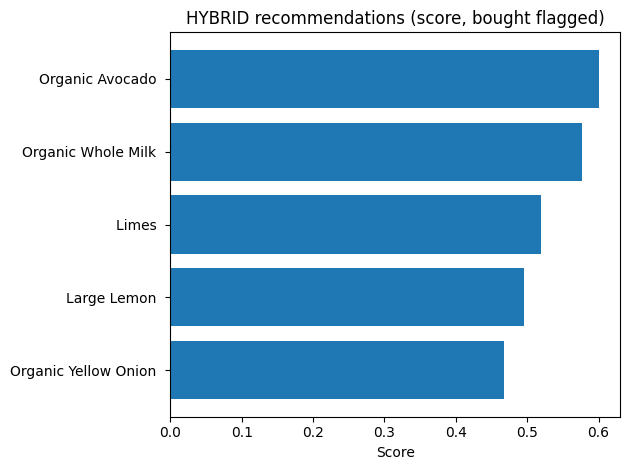

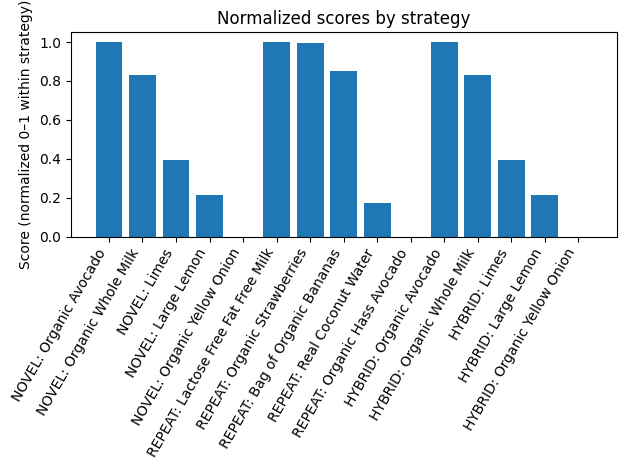

In [17]:
def _to_df(strategy_name, recs, future_names):
    """Convert recs to a tidy DataFrame."""
    rows = []
    for r in (recs or []):
        item = r["recommended_item"] if isinstance(r, dict) else r[0]
        score = float(r["score"] if isinstance(r, dict) else r[1])
        bought = item in future_names
        rows.append({"strategy": strategy_name, "item": item, "score": score, "bought": bought})
    return pd.DataFrame(rows)

# Build one DataFrame (skip empties safely)
parts = []
parts.append(_to_df("NOVEL",  recs_novel,  future_purchased_names))
parts.append(_to_df("REPEAT", recs_repeat, future_purchased_names))
parts.append(_to_df("HYBRID", recs_hybrid, future_purchased_names))
df_viz = pd.concat([p for p in parts if not p.empty], ignore_index=True) if any(not p.empty for p in parts) else pd.DataFrame(columns=["strategy","item","score","bought"])

def _plot_strategy(df, strategy):
    d = df[df["strategy"] == strategy].copy()
    if d.empty:
        print(f"No data for {strategy}")
        return
    d = d.sort_values("score", ascending=True)
    plt.figure()
    plt.title(f"{strategy} recommendations (score, bought flagged)")
    labels = [f"{it} {'✓' if b else ''}" for it, b in zip(d["item"], d["bought"])]
    plt.barh(labels, d["score"])
    plt.xlabel("Score")
    plt.tight_layout()
    plt.show()

# Plot per strategy
_plot_strategy(df_viz, "NOVEL")
_plot_strategy(df_viz, "REPEAT")
_plot_strategy(df_viz, "HYBRID")

def _normalize_scores_per_strategy(df):
    """Add score_norm ∈ [0,1] within each strategy."""
    if df.empty:
        return df.assign(score_norm=[])
    out = df.copy()
    out["score_norm"] = 0.0
    for s in out["strategy"].unique():
        mask = (out["strategy"] == s)
        vmin = out.loc[mask, "score"].min()
        vmax = out.loc[mask, "score"].max()
        if vmax == vmin:
            out.loc[mask, "score_norm"] = 1.0
        else:
            out.loc[mask, "score_norm"] = (out.loc[mask, "score"] - vmin) / (vmax - vmin)
    return out

df_norm = _normalize_scores_per_strategy(df_viz)

# Plot combined normalized scores (stacked by strategy blocks)
if not df_norm.empty:
    plt.figure()
    plt.title("Normalized scores by strategy")
    x_labels = [f"{s}: {it}" for s, it in zip(df_norm["strategy"], df_norm["item"])]
    plt.bar(x_labels, df_norm["score_norm"])
    plt.ylabel("Score (normalized 0–1 within strategy)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize (all strategies empty).")


<h3>⬆️ <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">⬆️ Quick read: NOVEL vs REPEAT vs HYBRID (per-user snapshot) ⬆️</span>⬆️</h3>

NOVEL chart:</br>Ranks new-to-user items via association rules. High scores reflect strong rule lift; absence of ✓ marks means those items did not appear in the user’s TRAIN purchases. Good for exploration, weaker for immediate hits.

REPEAT chart:</br>Prioritizes items the user already buys (frequency + recency). ✓ markers indicate TRAIN hits, so this view shows strong reorder potential and typically the highest precision.

HYBRID chart (α=0.6):</br>Blends NOVEL and REPEAT after per-list normalization. Here, the top results mirror NOVEL (few/no ✓), implying the blend leans toward exploration at α=0.6. For more reorders, lower α; for more discovery, raise α.

Combined normalized bars:</br>Scores are normalized within each strategy (0–1). Use this to compare ranking order inside each strategy, not absolute magnitudes across strategies.

⬆️Takeaway: Default to HYBRID (α≈0.6) for a balance. If accuracy/reorders are the priority, reduce α; if discovery is desired, increase α. For best overall performance, use adaptive α by user segment (repeaters → lower α, explorers → higher α).⬆️

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Alpha Tuning for HYBRID (Grid Search with Precision/Coverage/Novelty/Fβ)
</span></h3>

- Sweeps `alpha ∈ [0,1]` and evaluates HYBRID on a sampled user set (or FULL SCAN by uncommenting).  
- Per-α metrics: **Precision@5**, **Coverage@5**, **Novelty@5**, optional **Diversity@5** (`COMPUTE_DIVERSITY`), and **Fβ** (precision–novelty trade-off).  
- Prints a summary table + metric-vs-α plots; reports best α per objective.  
- Reproducible via `seed`; deterministic `alpha` grid.  
- **Inputs:** `recommend_hybrid`, `users_with_future`, `user_baskets`, `future_baskets`, `id_to_name` (and `product_to_users` if diversity ON).  
- **Outputs:** `summary` DataFrame (metrics per α) + console report + plots.

=== Alpha Tuning Summary (@k=5) ===
(seed=42, sample_size=2000, k=5, beta=0.5, diversity=False)
 alpha  Precision@5  Coverage@5  Novelty@5   F0.5
  0.00       0.3487         1.0     0.0513 0.1615
  0.05       0.3451         1.0     0.0645 0.1845
  0.10       0.3443         1.0     0.0721 0.1962
  0.15       0.3421         1.0     0.0848 0.2129
  0.20       0.3373         1.0     0.1052 0.2340
  0.25       0.3323         1.0     0.1361 0.2579
  0.30       0.3200         1.0     0.1828 0.2782
  0.35       0.3074         1.0     0.2280 0.2874
  0.40       0.2918         1.0     0.2788 0.2891
  0.45       0.2742         1.0     0.3252 0.2831
  0.50       0.2555         1.0     0.3707 0.2724
  0.55       0.2368         1.0     0.4190 0.2594
  0.60       0.2113         1.0     0.4777 0.2378
  0.65       0.1874         1.0     0.5318 0.2153
  0.70       0.1611         1.0     0.5874 0.1885
  0.75       0.1429         1.0     0.6242 0.1690
  0.80       0.1271         1.0     0.6587 0.1516
  0.

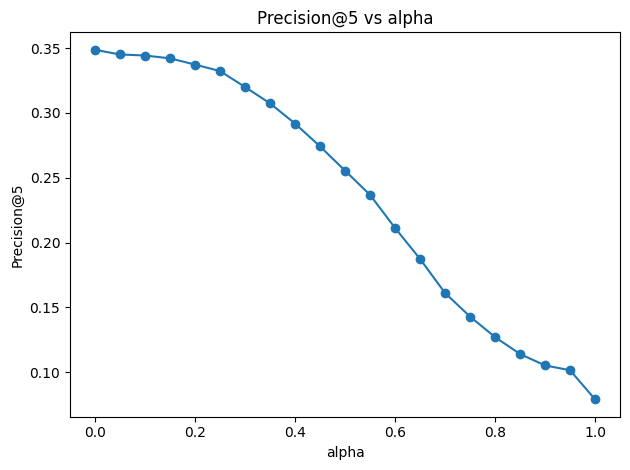

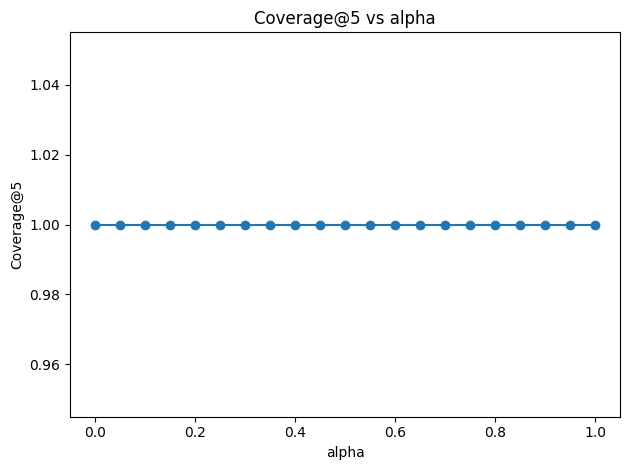

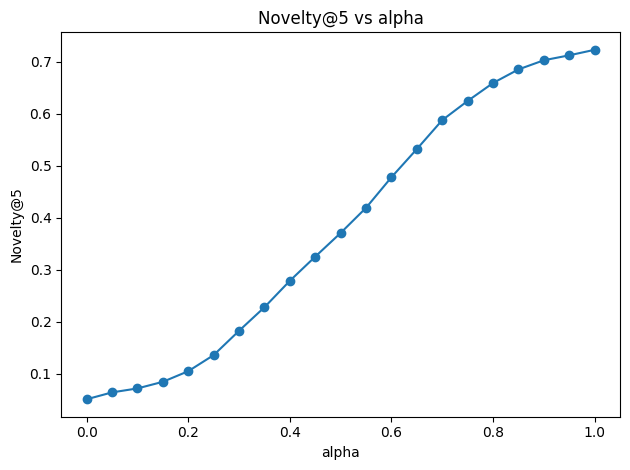

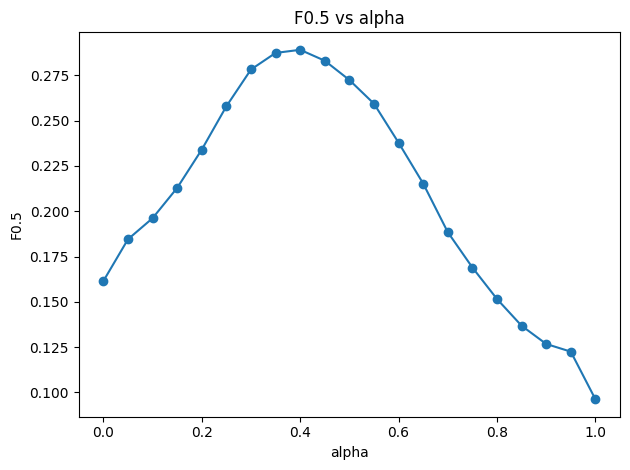

In [18]:
k = 5
seed = 42
sample_size = 2000
alphas = np.round(np.linspace(0.0, 1.0, 21), 2)  # 0.00..1.00
beta = 0.5  # F_beta: <1 favors precision, >1 favors novelty
COMPUTE_DIVERSITY = False  # set True to include Diversity@5 (needs product_to_users)

random.seed(seed)

# Choose evaluation population (use ONE line)
# sample_users = list(users_with_future)  # FULL SCAN
sample_users = random.sample(list(users_with_future), min(sample_size, len(users_with_future)))  # SAMPLE (default)

# Helpers
def _recommended_set_from_recs(recs):
    return {r["recommended_item"] for r in (recs or [])}

def _future_purchased_names(user_id):
    if user_id not in future_baskets:
        return set()
    return {id_to_name[p] for p in future_baskets[user_id] if p in id_to_name}

def _diversity_from_items(items):
    if not COMPUTE_DIVERSITY:
        return None
    items = list(items)
    if len(items) < 2:
        return 1.0
    distances = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            a, b = items[i], items[j]
            users_A = product_to_users.get(a, set())
            users_B = product_to_users.get(b, set())
            u = len(users_A | users_B)
            if u == 0:
                distances.append(1.0)
            else:
                inter = len(users_A & users_B)
                distances.append(1.0 - inter / u)
    return sum(distances) / len(distances)

def _avg(xs):
    xs = [x for x in xs if x is not None and not math.isnan(x)]
    return (sum(xs) / len(xs)) if xs else 0.0

def _f_beta(p, n, beta):
    if p == 0 and n == 0:
        return 0.0
    b2 = beta * beta
    denom = b2 * p + n
    return (1 + b2) * (p * n) / denom if denom > 0 else 0.0

# Evaluate each alpha
rows = []
for a in alphas:
    precs, novs, divs = [], [], []
    nonempty = 0
    for uid in sample_users:
        recs = recommend_hybrid(uid, top_k=k, alpha=float(a))
        if not recs:
            precs.append(None); novs.append(None); divs.append(None)
            continue
        nonempty += 1
        items = _recommended_set_from_recs(recs)
        fut = _future_purchased_names(uid)
        p = len(items & fut) / k
        prior_names = {id_to_name[x] for x in user_baskets.get(uid, set()) if x in id_to_name}
        n = len(items - prior_names) / k
        d = _diversity_from_items(items)
        precs.append(p); novs.append(n); divs.append(d)

    P = _avg(precs)
    N = _avg(novs)
    D = _avg(divs) if COMPUTE_DIVERSITY else None
    C = nonempty / len(sample_users) if sample_users else 0.0
    F = _f_beta(P, N, beta)

    row = {"alpha": float(a), "Precision@5": P, "Coverage@5": C, "Novelty@5": N, f"F{beta}": F}
    if COMPUTE_DIVERSITY:
        row["Diversity@5"] = D
    rows.append(row)

summary = pd.DataFrame(rows)

# Best alphas
best_precision_alpha = summary.loc[summary["Precision@5"].idxmax(), "alpha"]
best_novelty_alpha   = summary.loc[summary["Novelty@5"].idxmax(), "alpha"]
best_coverage_alpha  = summary.loc[summary["Coverage@5"].idxmax(), "alpha"]
best_fbeta_alpha     = summary.loc[summary[f"F{beta}"].idxmax(), "alpha"]
best_diversity_alpha = None
if COMPUTE_DIVERSITY and "Diversity@5" in summary.columns:
    best_diversity_alpha = summary.loc[summary["Diversity@5"].idxmax(), "alpha"]

print("=== Alpha Tuning Summary (@k=5) ===")
print(f"(seed={seed}, sample_size={len(sample_users)}, k={k}, beta={beta}, diversity={COMPUTE_DIVERSITY})")
print(summary.round(4).to_string(index=False))
print("\nBest alpha per objective:")
print(f"- Precision@5 : {best_precision_alpha}")
print(f"- Novelty@5   : {best_novelty_alpha}")
print(f"- Coverage@5  : {best_coverage_alpha}")
if COMPUTE_DIVERSITY:
    print(f"- Diversity@5 : {best_diversity_alpha}")
print(f"- F{beta} (trade-off P vs N): {best_fbeta_alpha}")

# Plots
plot_metrics = ["Precision@5", "Coverage@5", "Novelty@5", f"F{beta}"]
if COMPUTE_DIVERSITY:
    plot_metrics.insert(3, "Diversity@5")

for metric in plot_metrics:
    plt.figure()
    plt.title(f"{metric} vs alpha")
    plt.plot(summary["alpha"], summary[metric], marker="o")
    plt.xlabel("alpha"); plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


<h3> ⬆️<span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">⬆️ Alpha Sweep: how α reshapes Precision, Coverage, Novelty, and F⬆️<sub>0.5</sub> </span>⬆️</h3>
Precision@5 ↓ as α ↑: giving more weight to NOVEL (higher α) trades accuracy for exploration.</br>
Coverage@5 ≈ 1.0 (flat): the system returns recommendations across α; availability is not sensitive to α.</br>
Novelty@5 ↑ as α ↑: higher α surfaces more new-to-user items (plateaus near the top end).</br>
F<sub>0.5</sub> peaks ~α ≈ 0.35–0.40: with precision weighted more than novelty (β=0.5), the best trade-off favors more REPEAT (lower α).</br>
Actionable rules of thumb</br>
Optimize reorder accuracy → choose α ~ 0.3–0.4.</br>
Aim for balanced behavior → α ~ 0.5–0.6.</br>
Push discovery → α ≥ 0.7.</br>
For the best overall robustness, use the adaptive α by segment: lower for repeaters, higher for explorers.

<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Reusable Adaptive-4Seg Runner + Factory (no global mutations)
</span></h3>

- **`run_adaptive_4seg(...)`**: Encapsulates the full pipeline:
  1) Per-user grid-search over `alpha ∈ [0,1]` to find best α by **`precision`** or **`Fβ`**.  
  2) Computes each user’s **repeat_ratio** and assigns them to **4 quantile segments** (explorer, light-mixed, heavy-mixed, repeater).  
  3) Produces **segment-level α** as the **median** of per-user best α.  
  4) Returns artifacts (`adaptive_df`, `segment_alpha`, `quantiles`, `config`) without editing globals.
- **`make_adaptive_recommender(...)`**: Factory that returns a callable recommender using the learned **4-segment α**.  
  - Given a `user_id`, it computes `repeat_ratio`, picks the segment, applies its α, calls `recommend_hybrid`, and appends a short **rationale** to explanations.
- **Why**: Lets us run **multiple experiments** (e.g., baseline precision vs Fβ) in new cells **without** touching previous code or states.  
- **Inputs:** `recommend_hybrid`, `users_with_future`, `user_baskets`, `future_baskets`, `id_to_name`.  
- **Outputs:** `adaptive_df` (per-user best α, precision, novelty, repeat_ratio), `segment_alpha`, `quantiles`, `config`; plus an **adaptive recommender** ready for inference.

In [19]:
def run_adaptive_4seg(
    *,
    recommend_hybrid,                 # callable(user_id, top_k, alpha)
    users_with_future, user_baskets, future_baskets, id_to_name,
    k: int = 5,
    seed: int = 42,
    sample_size: int | None = 5000,
    sample_users: list[int] | None = None,
    alpha_grid = None,                # e.g. np.round(np.linspace(0,1,21),2)
    opt_metric: str = "precision",    # or "fbeta"
    beta: float = 1.0                 # used only if opt_metric == "fbeta"
):
    """Run per-user alpha grid-search, 4-quantile segmentation, and return artifacts."""
    rng = random.Random(seed)
    if sample_users is None:
        pop = list(users_with_future)
        if sample_size is None or sample_size >= len(pop):
            sample_users = pop
        else:
            sample_users = rng.sample(pop, sample_size)
    if alpha_grid is None:
        alpha_grid = np.round(np.linspace(0.0, 1.0, 21), 2)

    def _recommended_set_from_recs(recs):
        return {r["recommended_item"] for r in (recs or [])}

    def _future_purchased_names(user_id):
        if user_id not in future_baskets:
            return set()
        return {id_to_name[p] for p in future_baskets[user_id] if p in id_to_name}

    def _repeat_ratio(user_id):
        prior = {id_to_name[x] for x in user_baskets.get(user_id, set()) if x in id_to_name}
        fut = _future_purchased_names(user_id)
        return (len(prior & fut) / len(fut)) if fut else 0.0

    def _fbeta(p, n, beta_):
        if p == 0 and n == 0:
            return 0.0
        b2 = beta_ * beta_
        denom = b2 * p + n
        return (1 + b2) * (p * n) / denom if denom > 0 else 0.0

    rows = []
    for uid in sample_users:
        fut = _future_purchased_names(uid)
        if not fut:
            continue
        best_a, best_val = None, -1.0
        best_p, best_n = 0.0, 0.0
        for a in alpha_grid:
            recs = recommend_hybrid(uid, top_k=k, alpha=float(a))
            if not recs:
                continue
            items = _recommended_set_from_recs(recs)
            p = len(items & fut) / k
            prior_names = {id_to_name[x] for x in user_baskets.get(uid, set()) if x in id_to_name}
            n = len(items - prior_names) / k
            val = p if opt_metric == "precision" else _fbeta(p, n, beta)
            if val > best_val:
                best_val, best_a = val, float(a)
                best_p, best_n = p, n
        if best_a is None:
            continue
        rows.append({
            "user_id": uid,
            "best_alpha": best_a,
            "best_val": best_val,
            "best_precision": best_p,
            "best_novelty": best_n,
            "repeat_ratio": _repeat_ratio(uid)
        })

    adaptive_df = pd.DataFrame(rows)
    if adaptive_df.empty:
        return {
            "adaptive_df": adaptive_df,
            "segment_alpha": {},
            "quantiles": {},
            "config": {
                "k": k, "seed": seed, "sample_size": sample_size,
                "alpha_grid": list(map(float, alpha_grid)),
                "opt_metric": opt_metric, "beta": beta,
                "evaluated_users": 0
            }
        }

    qs = adaptive_df["repeat_ratio"].quantile([0.25, 0.50, 0.75]).to_dict()
    q25, q50, q75 = qs[0.25], qs[0.50], qs[0.75]

    def _segment4(rr: float) -> str:
        if rr <= q25:  return "explorer"
        if rr <= q50:  return "light-mixed"
        if rr <= q75:  return "heavy-mixed"
        return "repeater"

    adaptive_df["segment"] = adaptive_df["repeat_ratio"].apply(_segment4)
    segment_alpha = (
        adaptive_df.groupby("segment")["best_alpha"]
        .median()
        .to_dict()
    )

    return {
        "adaptive_df": adaptive_df,
        "segment_alpha": segment_alpha,
        "quantiles": {"q25": float(q25), "q50": float(q50), "q75": float(q75)},
        "config": {
            "k": k, "seed": seed, "sample_size": sample_size,
            "alpha_grid": list(map(float, alpha_grid)),
            "opt_metric": opt_metric, "beta": beta,
            "evaluated_users": int(adaptive_df["user_id"].nunique())
        }
    }

def make_adaptive_recommender(segment_alpha: dict, quantiles: dict, *, default_alpha: float = 0.5):
    """Return a callable(user_id, top_k) that applies 4-quantile segments to pick alpha."""
    q25, q50, q75 = quantiles.get("q25", 0.25), quantiles.get("q50", 0.50), quantiles.get("q75", 0.75)
    def _adaptive(user_id: int, *, recommend_hybrid, user_baskets, future_baskets, id_to_name, top_k: int = 5):
        def _future_bought(u: int):
            if u not in future_baskets: return set()
            return {id_to_name[p] for p in future_baskets[u] if p in id_to_name}
        prior = {id_to_name[x] for x in user_baskets.get(user_id, set()) if x in id_to_name}
        fut = _future_bought(user_id)
        rr = (len(prior & fut) / len(fut)) if fut else 0.0
        if rr <= q25: seg = "explorer"
        elif rr <= q50: seg = "light-mixed"
        elif rr <= q75: seg = "heavy-mixed"
        else: seg = "repeater"
        a = float(segment_alpha.get(seg, default_alpha))
        recs = recommend_hybrid(user_id, top_k=top_k, alpha=a)
        for r in recs:
            r.setdefault("explanations", []).append(f"(adaptive-4seg) segment={seg}, alpha={a:.2f}, rr={rr:.2f}")
        return recs
    return _adaptive


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Baseline vs Fβ runs + segment α deltas + mean(best_precision/novelty) per run
</span></h3>

- Runs `run_adaptive_4seg` twice: **precision** baseline and **Fβ (β=1.0)**.  
- Prints quantiles, segment α medians, **Δα per segment**, and the **means of best_precision / best_novelty** across users for each run.  
- Uses existing `run_adaptive_4seg`/`make_adaptive_recommender`; no globals mutated.

In [20]:
# Baseline: precision-only
res_prec = run_adaptive_4seg(
    recommend_hybrid=recommend_hybrid,
    users_with_future=users_with_future,
    user_baskets=user_baskets,
    future_baskets=future_baskets,
    id_to_name=id_to_name,
    k=5, seed=42, sample_size=5000,
    alpha_grid=np.round(np.linspace(0.0, 1.0, 21), 2),
    opt_metric="precision", beta=1.0  # beta ignored
)
print("=== Baseline (precision) ===")
print("Users evaluated:", res_prec["config"]["evaluated_users"])
print("Quantiles:", {k: round(v,4) for k,v in res_prec["quantiles"].items()})
print("Segment α:", {k: round(v,2) for k,v in res_prec["segment_alpha"].items()})

# Fβ run (β=1.0)
res_fbeta = run_adaptive_4seg(
    recommend_hybrid=recommend_hybrid,
    users_with_future=users_with_future,
    user_baskets=user_baskets,
    future_baskets=future_baskets,
    id_to_name=id_to_name,
    k=5, seed=42, sample_size=5000,
    alpha_grid=np.round(np.linspace(0.0, 1.0, 21), 2),
    opt_metric="fbeta", beta=1.0
)
print("\n=== Fβ run (beta=1.0) ===")
print("Users evaluated:", res_fbeta["config"]["evaluated_users"])
print("Quantiles:", {k: round(v,4) for k,v in res_fbeta["quantiles"].items()})
print("Segment α:", {k: round(v,2) for k,v in res_fbeta["segment_alpha"].items()})

# Segment α side-by-side deltas
segments = sorted(set(res_prec["segment_alpha"]) | set(res_fbeta["segment_alpha"]))
cmp = pd.DataFrame({
    "segment": segments,
    "alpha_precision": [res_prec["segment_alpha"].get(s, np.nan) for s in segments],
    "alpha_fbeta":     [res_fbeta["segment_alpha"].get(s, np.nan) for s in segments],
})
cmp["delta"] = (cmp["alpha_fbeta"] - cmp["alpha_precision"]).round(3)
print("\n=== Segment α comparison ===")
print(cmp.to_string(index=False))

# Mean(best_precision) & Mean(best_novelty) per run
def _mean_safe(s):
    s = pd.Series(s).dropna()
    return float(s.mean()) if not s.empty else float("nan")

def _summarize_means(tag, df):
    mp = _mean_safe(df.get("best_precision", pd.Series(dtype=float)))
    mn = _mean_safe(df.get("best_novelty", pd.Series(dtype=float)))
    return {"run": tag, "mean_best_precision": round(mp, 4), "mean_best_novelty": round(mn, 4)}

means_df = pd.DataFrame([
    _summarize_means("precision", res_prec["adaptive_df"]),
    _summarize_means("fbeta(β=1.0)", res_fbeta["adaptive_df"]),
])
print("\n=== Mean of per-user best metrics ===")
print(means_df.to_string(index=False))

=== Baseline (precision) ===
Users evaluated: 5000
Quantiles: {'q25': 0.3846, 'q50': 0.6461, 'q75': 0.8733}
Segment α: {'explorer': 0.0, 'heavy-mixed': 0.0, 'light-mixed': 0.0, 'repeater': 0.0}

=== Fβ run (beta=1.0) ===
Users evaluated: 5000
Quantiles: {'q25': 0.3846, 'q50': 0.6461, 'q75': 0.8733}
Segment α: {'explorer': 0.0, 'heavy-mixed': 0.4, 'light-mixed': 0.35, 'repeater': 0.35}

=== Segment α comparison ===
    segment  alpha_precision  alpha_fbeta  delta
   explorer              0.0         0.00   0.00
heavy-mixed              0.0         0.40   0.40
light-mixed              0.0         0.35   0.35
   repeater              0.0         0.35   0.35

=== Mean of per-user best metrics ===
         run  mean_best_precision  mean_best_novelty
   precision               0.3528             0.0628
fbeta(β=1.0)               0.2753             0.3391


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Time-Decay for Repeat Scoring (half-life by order index)
</span></h3>

- Adds exponential **recency weight**: `decay = 0.5 ** ((Umax - last_order_number)/HALFLIFE_ORDERS)`.  
- New repeat score: `score_repeat = freq * decay + RECENCY_LAMBDA * norm_last_onum`.  
- Toggle via `USE_TIME_DECAY`; no upstream changes required.


In [21]:
# --- Time-decay config ---
USE_TIME_DECAY = True
HALFLIFE_ORDERS = 4.0   # half-life in "order_number" units
RECENCY_LAMBDA = 0.5    # already used in your repeat score

def _compute_decay_series(df: pd.DataFrame) -> pd.Series:
    if df.empty:
        return pd.Series(dtype=float)
    u_max = df.groupby("user_id")["last_order_number"].transform("max")
    age = (u_max - df["last_order_number"]).astype(float)
    decay = 0.5 ** (age / max(HALFLIFE_ORDERS, 1e-6))
    return decay

def recommend_repeats(user_id: int, top_k: int = 5):
    if user_id not in user_baskets:
        return []
    subset = user_item_stats[user_item_stats["user_id"] == user_id]
    if subset.empty and "user_item_stats_full" in globals():
        subset = user_item_stats_full[user_item_stats_full["user_id"] == user_id].copy()
        if subset.empty:
            return []
        # ensure norm_last_onum
        umin, umax = subset["last_order_number"].min(), subset["last_order_number"].max()
        subset["norm_last_onum"] = 1.0 if umax == umin else (subset["last_order_number"] - umin) / (umax - umin)

    tmp = subset.copy()
    if USE_TIME_DECAY:
        tmp["decay"] = _compute_decay_series(tmp)
        tmp["score_repeat"] = tmp["freq"] * tmp["decay"] + RECENCY_LAMBDA * tmp["norm_last_onum"]
    else:
        tmp["score_repeat"] = tmp["freq"] + RECENCY_LAMBDA * tmp["norm_last_onum"]

    tmp["__name"] = tmp["product_id"].apply(lambda pid: id_to_name.get(pid, f"product_id={pid}"))
    tmp = tmp.sort_values(["score_repeat", "__name"], ascending=[False, True]).head(top_k)

    results = []
    for _, row in tmp.iterrows():
        name = row["__name"]
        freq = int(row["freq"])
        recn = float(row["norm_last_onum"])
        parts = [f"you bought it {freq} times", f"recency={recn:.2f}"]
        if USE_TIME_DECAY:
            parts.append(f"decay={float(row['decay']):.2f}")
        results.append({"recommended_item": name, "score": float(row["score_repeat"]), "explanations": [", ".join(parts)]})
    return results


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Popularity Debias (cap/penalty for very popular items)
</span></h3>

- Computes item popularity from `product_to_users`.  
- Two modes:
  - **"filter"**: drop items above `pop_quantile` (e.g., top 5%).  
  - **"penalty"**: scale scores by `1 / (1 + γ·pop_norm)`.  
- Applies to any rec list; integrate before display/eval if desired.


In [22]:
# --- Popularity config ---
POP_CAP_MODE = "none"      # "none" | "filter" | "penalty"
POP_QUANTILE = 0.95        # used when POP_CAP_MODE="filter"
POP_PENALTY_GAMMA = 1.0    # used when POP_CAP_MODE="penalty"

# Build popularity dict once
_item_pop = {}
if "product_to_users" in globals() and product_to_users:
    _item_pop = {item: len(uids) for item, uids in product_to_users.items()}
    pops = list(_item_pop.values())
    _pmin, _pmax = min(pops), max(pops)
    _pop_q = np.quantile(pops, POP_QUANTILE) if pops else float("inf")
else:
    _pmin, _pmax, _pop_q = 0, 1, float("inf")

def _apply_popularity_cap(recs: list[dict]) -> list[dict]:
    if not recs or POP_CAP_MODE == "none":
        return recs
    if POP_CAP_MODE == "filter":
        out = []
        for r in recs:
            pop = _item_pop.get(r["recommended_item"], 0)
            if pop <= _pop_q:
                out.append(r)
        return out
    if POP_CAP_MODE == "penalty":
        out = []
        for r in recs:
            pop = _item_pop.get(r["recommended_item"], _pmin)
            pop_norm = 0.0 if _pmax == _pmin else (pop - _pmin) / (_pmax - _pmin)
            scale = 1.0 / (1.0 + POP_PENALTY_GAMMA * pop_norm)
            r2 = dict(r)
            r2["score"] = float(r["score"]) * float(scale)
            r2.setdefault("explanations", []).append(f"(pop penalty: scale={scale:.2f})")
            out.append(r2)
        # keep deterministic order after score change
        return sorted(out, key=lambda x: (-x["score"], x["recommended_item"]))
    return recs

# Optional wrappers if you want to apply debias automatically:
def recommend_with_explanations_debiased(user_id: int, top_k: int = 5, allow_repeat: bool = False):
    base = recommend_with_explanations(user_id, top_k=top_k, allow_repeat=allow_repeat)
    return _apply_popularity_cap(base)

def recommend_hybrid_debiased(user_id: int, top_k: int = 5, alpha: float = 0.6):
    base = recommend_hybrid(user_id, top_k=top_k, alpha=alpha)
    return _apply_popularity_cap(base)


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Cold-Start Fallbacks (no PRIOR or empty recs)
</span></h3>

- Global **popular** fallback from PRIOR (`product_to_users`).  
- Strategy-level helpers return fallback when base recs are empty.  
- Keeps existing APIs intact; call these in demos/eval if you want safety.


In [23]:
# Precompute global popular list
if "product_to_users" in globals() and product_to_users:
    _global_pop = sorted(
        [{"recommended_item": it, "score": len(uids), "explanations": ["global popular"]} for it, uids in product_to_users.items()],
        key=lambda x: (-x["score"], x["recommended_item"])
    )
else:
    _global_pop = []

def _fallback_global_pop(top_k: int = 5):
    return _global_pop[:top_k] if _global_pop else []

def recommend_novel_with_fallback(user_id: int, top_k: int = 5):
    recs = recommend_with_explanations(user_id, top_k=top_k, allow_repeat=False)
    return recs if recs else _fallback_global_pop(top_k)

def recommend_repeat_with_fallback(user_id: int, top_k: int = 5):
    recs = recommend_repeats(user_id, top_k=top_k)
    return recs if recs else _fallback_global_pop(top_k)

def recommend_hybrid_with_fallback(user_id: int, top_k: int = 5, alpha: float = 0.6):
    recs = recommend_hybrid(user_id, top_k=top_k, alpha=alpha)
    return recs if recs else _fallback_global_pop(top_k)


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
PCY Footprint Diagnostics (collision & bitmap density)
</span></h3>

- Lightweight diagnostics if you have PCY artifacts in-memory.  
- Expected optional vars: `pcy_bucket_counts` (array-like), `bitmap` (0/1 list), `num_pairs_hashed`.  
- Prints collision proxy and density; safe if artifacts are missing.


In [24]:
def pcy_diagnostics(pcy_bucket_counts=None, bitmap=None, num_pairs_hashed=None):
    if pcy_bucket_counts is None or bitmap is None:
        print("[PCY] Artifacts not found. Provide pcy_bucket_counts (array-like) and bitmap (0/1).")
        return
    counts = np.asarray(pcy_bucket_counts, dtype=np.int64)
    bm = np.asarray(bitmap, dtype=np.int8)
    m = len(counts)
    hot = int(bm.sum())
    cold = int(m - hot)
    density = hot / m if m else 0.0
    nonzero = int((counts > 0).sum())
    collisions = int((counts >= 2).sum())
    hashed = int(num_pairs_hashed) if num_pairs_hashed is not None else int(counts.sum())
    print("=== PCY Footprint ===")
    print(f"Buckets           : {m}  | Hot (bitmap=1): {hot}  | Cold: {cold}  | Density: {density:.4f}")
    print(f"Nonzero buckets   : {nonzero}  | Collisions (>=2 in same bucket): {collisions}")
    print(f"Pairs hashed (est): {hashed}")
    if m:
        print(f"Avg load per bucket: {counts.sum()/m:.3f}")
    if hot:
        print(f"Avg load per HOT bucket: {counts[bm==1].mean():.3f}")

# Example usage (only if you already have those arrays):
# pcy_diagnostics(pcy_bucket_counts, bitmap, num_pairs_hashed)


<h3> <span style="; color:green; font-weight:bold; background-color:#f0f0f0; padding:6px; border-radius:4px; font-size:20px;">
Exports for Report (CSV/JSON)
</span></h3>

- Saves key artifacts for your write-up: rules, eval summary, adaptive runs, and sample user viz.  
- Optional; skip any block if the variable doesn’t exist.


In [25]:
# Exports are optional; enable flags to write files
SAVE_RULES = True
SAVE_EVAL_SUMMARY = True
SAVE_ADAPTIVE = True
SAVE_SAMPLE_VIZ = True

# Base save directory (will be created if missing)
SAVE_DIR = os.path.normpath("../../data/Georgios/pcy_recomender")
os.makedirs(SAVE_DIR, exist_ok=True)

def _save_df(df, filename, msg=None):
    """Tiny helper to save a DataFrame safely."""
    full_path = os.path.join(SAVE_DIR, filename)
    df.to_csv(full_path, index=False)
    print(f"[saved] {full_path}" if msg is None else f"[saved] {full_path}  | {msg}")

# 1) Rules
if SAVE_RULES and "df_rules_dedup" in globals():
    _save_df(df_rules_dedup, "rules_dedup.csv")

# 2) Evaluation summary (from your eval cell)
if SAVE_EVAL_SUMMARY and "summary" in globals():
    _save_df(summary, "eval_comparison_k5.csv")

# 3) Adaptive runs (if you ran them)
if SAVE_ADAPTIVE and "res_prec" in globals() and "res_fbeta" in globals():
    _save_df(res_prec["adaptive_df"], "adaptive_precision.csv")
    _save_df(res_fbeta["adaptive_df"], "adaptive_fbeta_b1.csv")

    seg_prec = pd.DataFrame([{"segment": k, "alpha": v} for k, v in res_prec["segment_alpha"].items()])
    seg_fbeta = pd.DataFrame([{"segment": k, "alpha": v} for k, v in res_fbeta["segment_alpha"].items()])
    _save_df(seg_prec,  "seg_alpha_precision.csv")
    _save_df(seg_fbeta, "seg_alpha_fbeta_b1.csv")
    print("[saved] adaptive_* and seg_alpha_*")

# 4) Random-user viz data
if SAVE_SAMPLE_VIZ and "df_viz" in globals():
    _save_df(df_viz, "sample_user_viz.csv")

[saved] ..\..\data\Georgios\pcy_recomender\rules_dedup.csv
[saved] ..\..\data\Georgios\pcy_recomender\eval_comparison_k5.csv
[saved] ..\..\data\Georgios\pcy_recomender\adaptive_precision.csv
[saved] ..\..\data\Georgios\pcy_recomender\adaptive_fbeta_b1.csv
[saved] ..\..\data\Georgios\pcy_recomender\seg_alpha_precision.csv
[saved] ..\..\data\Georgios\pcy_recomender\seg_alpha_fbeta_b1.csv
[saved] adaptive_* and seg_alpha_*
[saved] ..\..\data\Georgios\pcy_recomender\sample_user_viz.csv
